In [1]:
import numpy
import scipy
from os.path import join
import matplotlib.pyplot as plt
import texplot
from pprint import pprint

import freealg
from freealg import AlgebraicForm
from freealg.visualization import plot_flow, plot_mass, ridgeplot

plot_dir = './plots'

In [2]:
filename = 'Umatrix64k_eigs.npz'
dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
data = numpy.load(join(dir_, filename), allow_pickle=True)
out = data['out'].item()

sizes = out['sizes']
eigs = out['eigs']
wall_times = out['wall_times']
proc_times = out['proc_times']
n, p = out['shape']

for i in range(sizes.size):
    print(f'{i:>2d}: {sizes[i]:>6d}')

 0:   1000
 1:   2000
 2:   4000
 3:   8000
 4:  16000
 5:  32000
 6:  64000


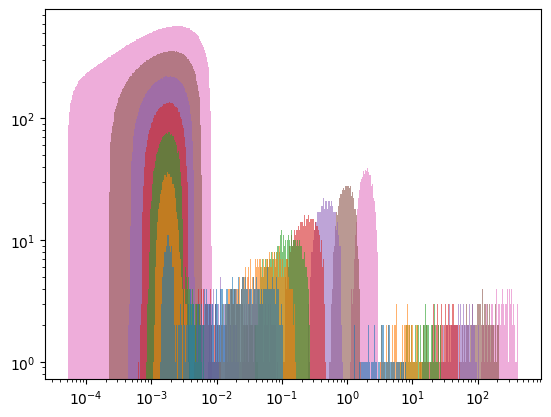

In [3]:
for i in range(len(eigs)):
    x_min = numpy.min(eigs[i])
    mask = numpy.abs(eigs[i]) > x_min
    x_max = numpy.max(eigs[i])
    bins = numpy.geomspace(x_min, x_max, 500)
    plt.hist(eigs[i][mask], bins, zorder=-i, alpha=0.6)

plt.xscale('log')
plt.yscale('log')
plt.show()

In [5]:
def support_from_hist(array, tol=0.0, nbins=1000, log=False):
    """
    vals  : histogram heights (len = n_bins)
    edges : histogram bin edges (len = n_bins + 1)
    tol   : treat vals <= tol as zero
    returns list of (left_edge, right_edge)
    """

    x_min = numpy.min(array)
    x_max = numpy.max(array)

    if log:
        x = numpy.geomspace(x_min, x_max, nbins)
    else:
        x = numpy.geomspace(x_min, x_max, nbins)
        
    eig_init = eigs[start_idx]
    supp_init = [numpy.min(eig_init), numpy.max(eig_init)]
    bins = numpy.geomspace(supp_init[0], supp_init[1], 150)
    vals, edges = numpy.histogram(eig_init, bins=bins, density=True)
    
    nz = vals > tol
    if not numpy.any(nz):
        return []

    # Find starts/ends of contiguous True blocks
    d = numpy.diff(nz.astype(int))
    starts = numpy.r_[0, numpy.where(d == 1)[0] + 1] if nz[0] else numpy.where(d == 1)[0] + 1
    ends = numpy.r_[numpy.where(d == -1)[0] + 1, len(nz)] if nz[-1] else numpy.where(d == -1)[0] + 1

    return [(float(edges[s]), float(edges[e])) for s, e in zip(starts, ends)]

In [90]:
start_idx = 2

support = support_from_hist(eigs[start_idx], tol=0, nbins=1000, log=True)
print('Support from hist:')
for supp in support:
    print(f'{supp[0]:>0.4f}, {supp[1]:>0.4f}')
print('')

af = AlgebraicForm(eigs[start_idx],
                   # support=support,
                   support=None,
                   delta=1e-8)

deg_m = 5
deg_z = 1

coeffs = af.fit(
    deg_m, deg_z, reg=0,
    # r=[1.25, 6, 10],
    # n_r=[3, 2, 1],
    # n_samples=4096,
    # y_eps=1e-3,
    # x_pad=0.0,
    normalize=True, triangular=None,
    mu='auto', mu_reg=0, verbose=True)

print('\nSupport:')
est_supp = af.support()
print(est_supp)

print('\nAtoms:')
print(af.atoms())

Support from hist:
0.0007, 0.0064
0.0377, 0.2727
6.1221, 27.0271

fit residual max  : 2.5865e+00
fit residual 99.9%: 1.9150e+00

Coefficients (real)
+0.99999173 +14.16717148 +1.45789166 +0.00116185 -0.00000916 +0.00000000 
+0.00000000 +1.00006738 +14.60136517 +1.84358664 +0.00577178 +0.00000075 

Coefficients (imag) norm: 0.0000e+00

	frac_bad: 1.000
	n_bad   : 128
	n_test  : 128

Support:
[(0.04266494220429637, 0.24451132933240285), (10.03316315500508, 19.777217003805422)]

Atoms:
[(-0.0004523993701152114, 1.7972834768909526e-09)]


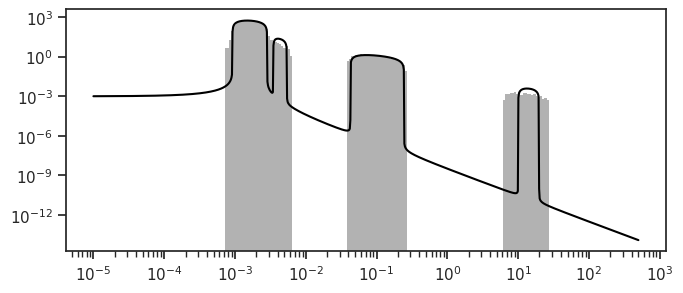

In [91]:
x_min = 1e-5
x_max = 500
x = numpy.geomspace(x_min, x_max, 1000)
rho0 = af.density(x)

with texplot.theme(use_latex=False):

    fig, ax = plt.subplots(figsize=(7, 3.1))
    
    eig_init = eigs[start_idx]
    supp_init = [numpy.min(eig_init), numpy.max(eig_init)]
    bins = numpy.geomspace(supp_init[0], supp_init[1], 150)
    vals, edges = numpy.histogram(eig_init, bins=bins, density=True)
    ax.stairs(vals, edges, fill=True, zorder=-1, alpha=0.6, color='gray')
    ax.plot(x, rho0, color='black')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    plt.tight_layout()
    plt.show()

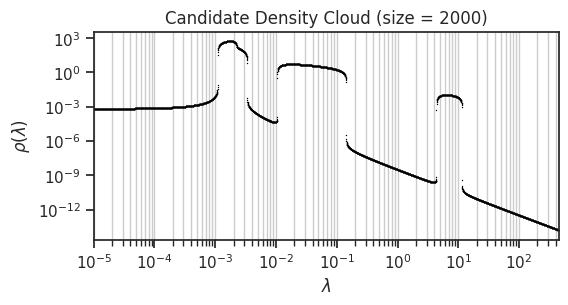

In [15]:
x_highres = numpy.geomspace(x_min, x_max, 5000)
af.candidates(size=sizes[start_idx], x=x_highres, log=True, delta=1e-8,
              markersize=1)

success rate per t: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


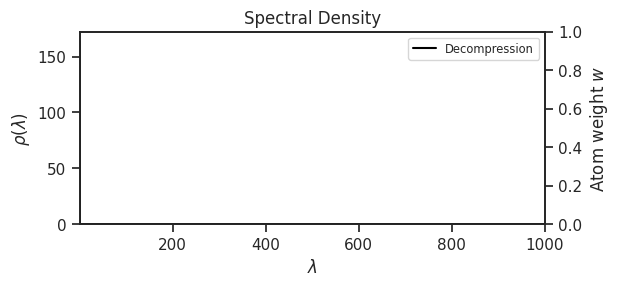

In [76]:
end_idx = sizes.size - 1
fd_sizes = sizes[start_idx:end_idx+1]

x_min = 1e-3
x_max = 1e3
x = numpy.geomspace(x_min, x_max, 1000)

newton_opt = dict(
    dt_max=0.02,
)

rho, x, atoms = af.decompress(
    fd_sizes, x=x, method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=True,
    atom_eps=None,
    verbose=True, plot=True, latex=False)

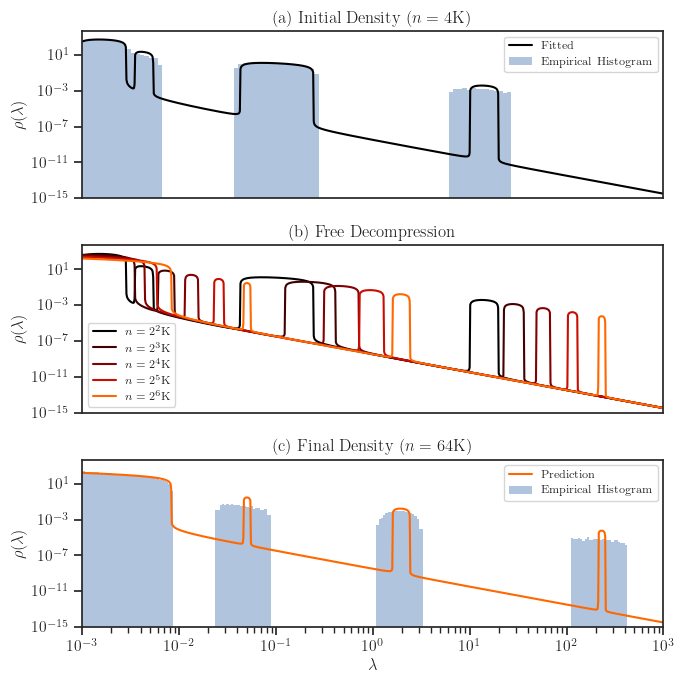

In [79]:
def _decimal_text(val, mode):
    """
    Decimal text for plot legends.
    """

    if mode == 'int':
        label = rf'$n={{{val:>0.0f}}}$K'
    elif mode == 'dec':
        label = rf'$n={{{val:>0.1f}}}$K'
    elif mode in ['pow-int']:
        if numpy.abs(val - 1.0) < 1e-8:
            label = r'$n=1$K'
        elif numpy.abs(val - 2.0) < 1e-8:
            label = r'$n=2$K'
        else:
            label = rf'$n=2^{{{numpy.log2(val):>0.0f}}}$K'
    elif mode in ['pow-dec']:
        label = rf'$n=2^{{{numpy.log2(val):>0.1f}}}$K'
    else:
        raise ValueError('"mode" is invalid.')

    return label

from matplotlib.ticker import NullLocator

def plot_flow(sizes, x, rho, eig_init=None, eig_final=None, xlim=None, ylim=None, 
              sharey=False, cmap=None, c_range=None, hist_color=None, nbins=(80, 120),
              label_mode='int', save=False, latex=False):

    num_plots = rho.shape[0]

    if cmap is None:
        cmap = plt.get_cmap('gist_heat')
        c_range_ = (0, 0.7)

        # cmap = plt.get_cmap('ocean')
        # c_range_ = (0.3, 0.75)
        #
        # cmap = cc.cm.CET_CBL2
        # c_range_ = (0, 0.5)

        if c_range is None:
            c_range = c_range_

    elif c_range is None:
        c_range = (0, 1)

    if numpy.isscalar(nbins):
        nbins = (nbins, nbins)

    colors = cmap(numpy.linspace(c_range[0], c_range[1], num_plots))

    if hist_color is None:
        hist_color = 'lightsteelblue'

    with texplot.theme(use_latex=latex):
    
        fig, ax = plt.subplots(figsize=(7, 7), nrows=3, sharey=sharey)

        ax[0].plot(x, rho[0], color=colors[0], label='Fitted', zorder=1)
    
        supp_init = [numpy.min(eig_init), numpy.max(eig_init)]
        bins = numpy.geomspace(supp_init[0], supp_init[1], nbins[0])
        vals, edges = numpy.histogram(eig_init, bins=bins, density=True)
        ax[0].stairs(vals, edges, fill=True, zorder=-1, alpha=1.0,
                     color=hist_color, label='Empirical Histogram')

        for i in range(rho.shape[0]):
            label = _decimal_text(sizes[i] / 1000.0, label_mode)
            ax[1].plot(x, rho[i], color=colors[i], label=label)

        ax[-1].plot(x, rho[-1], color=colors[-1], label='Prediction', zorder=1)
        
        supp_final = [numpy.min(eig_final), numpy.max(eig_final)]
        bins = numpy.geomspace(supp_final[0], supp_final[1], nbins[1])
        vals, edges = numpy.histogram(eig_final, bins=bins, density=True)
        ax[-1].stairs(vals, edges, fill=True, zorder=-1, alpha=1.0,
                      color=hist_color, label='Empirical Histogram')
            
        if ylim is None:
            ylim = numpy.array([
                0.5 * float(numpy.min(rho)),
                2.0 * float(numpy.max(rho))])
        else:
            ylim = numpy.atleast_1d(ylim)

        # if ylim.size == 1:
        #     ylim = numpy.tile(ylim, len(ax))

        if xlim is None:
            xlim = [numpy.min(x), numpy.max(x)]

        for i in range(len(ax)):
            ax[i].set_xlim(xlim)
            ax[i].set_xlabel(r'$\lambda$')
            ax[i].set_ylabel(r'$\rho(\lambda)$')
            ax[i].legend(fontsize='x-small', facecolor='none')
            ax[i].set_xscale('log')
            ax[i].set_yscale('log')

        if sharey:
            ax[i].set_ylim(ylim)
        else:
            for i in range(len(ax)):
                ax[i].set_ylim(ylim)

        if sharey:
            for i in range(0, len(ax)-1):
                # ax[i].tick_params(left=False, labelleft=False)
                ax[i].set_xlabel('')
                ax[i].xaxis.set_major_locator(NullLocator())
                ax[i].xaxis.set_minor_locator(NullLocator())
                ax[i].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

        ax[0].set_title(
            rf'(a) Initial Density ($n={{{sizes[0]/1000:>0.0f}}}$K)')
        ax[1].set_title(r'(b) Free Decompression')
        ax[2].set_title(
            rf'(c) Final Density ($n={{{sizes[-1]/1000:>0.0f}}}$K)')
        
        plt.tight_layout()

        if sharey:
            fig.subplots_adjust(wspace=0.03)
        else:
            fig.subplots_adjust(wspace=0.18)

        if save is False:
            save_status = False
            save_filename = ''
        else:
            save_status = True
            if isinstance(save, str):
                save_filename = save
            else:
                save_filename = 'flow.pdf'

        texplot.show_or_save_plot(plt, default_filename=save_filename,
                                  transparent_background=True, dpi=200,
                                  show_and_save=save_status, verbose=True)

# ---------

plot_flow(fd_sizes, x, rho,
          eig_init=eigs[start_idx],
          eig_final=eigs[end_idx],
          xlim=(1e-3, 1e3),
          ylim=(1e-15, 5e3),
          # ylim=None,
          nbins=(100, 300),
          sharey=True,
          label_mode='pow-int',
          latex=True)

In [56]:
# plot_mass(fd_sizes, x, rho, atoms=None, log_x=True, gap=0.7, save=False)